# US Airline Routes & Fares — Exploratory Data Analysis

This notebook explores the U.S. Airline Flight Routes and Fares dataset covering 1993–2024.

The analysis examines airfare, passenger volume, route distance, carrier market share, and relationships among key airline market variables.

In [32]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm

## 1. Load the Dataset

Load the U.S. Airline Flight Routes and Fares dataset into a Pandas DataFrame and preview the first five observations.

In [33]:
# Load the dataset
df = pd.read_csv(
    "data/US_Airline_Fares.csv",
    low_memory=False
)

df.head()

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


## 2. Initial Data Inspection

Examine the structure and quality of the dataset, including its dimensions, columns, data types, missing values, and duplicate observations.

In [34]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types and non-null counts
print("\nDataset information:")
df.info()

Dataset shape: (245955, 23)

Column names:
['tbl', 'Year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1', 'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2', 'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg', 'carrier_low', 'lf_ms', 'fare_low', 'Geocoded_City1', 'Geocoded_City2', 'tbl1apk']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  str    
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  str    
 6   city2           245955 non-null  str    
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  s

In [35]:
# Check the number of missing values in each column
print("Missing values:")
print(df.isna().sum())

# Calculate missing-value percentages
print("\nMissing values (%):")
print((df.isna().sum() / len(df) * 100).round(2))

Missing values:
tbl                   0
Year                  0
quarter               0
citymarketid_1        0
citymarketid_2        0
city1                 0
city2                 0
airportid_1           0
airportid_2           0
airport_1             0
airport_2             0
nsmiles               0
passengers            0
fare                  0
carrier_lg         1540
large_ms           1540
fare_lg            1540
carrier_low        1612
lf_ms              1612
fare_low           1612
Geocoded_City1    39206
Geocoded_City2    39206
tbl1apk               0
dtype: int64

Missing values (%):
tbl                0.00
Year               0.00
quarter            0.00
citymarketid_1     0.00
citymarketid_2     0.00
city1              0.00
city2              0.00
airportid_1        0.00
airportid_2        0.00
airport_1          0.00
airport_2          0.00
nsmiles            0.00
passengers         0.00
fare               0.00
carrier_lg         0.63
large_ms           0.63
fare_lg       

In [36]:
# Check for completely duplicated rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## 3. Missing-Value Pattern Investigation

Investigate whether related carrier variables are missing together. This helps determine whether the missing values follow a consistent pattern across carrier market-share and fare variables.

In [37]:
# Check whether largest-carrier fields are missing together
print(
    df[df["carrier_lg"].isna()][
        ["carrier_lg", "large_ms", "fare_lg"]
    ].isna().sum()
)

# Check whether lowest-fare-carrier fields are missing together
print(
    df[df["carrier_low"].isna()][
        ["carrier_low", "lf_ms", "fare_low"]
    ].isna().sum()
)

carrier_lg    1540
large_ms      1540
fare_lg       1540
dtype: int64
carrier_low    1612
lf_ms          1612
fare_low       1612
dtype: int64


## 4. Descriptive Statistics

Examine summary statistics for key numerical variables, including route distance, passenger volume, airfare, and carrier market shares.

In [38]:
# Summary statistics for year, quarter, route distance, and passengers
print(
    df[["Year", "quarter", "nsmiles", "passengers"]].describe()
)

# Summary statistics for carrier market share and fare variables
print(
    df[["large_ms", "fare_lg", "lf_ms", "fare_low"]].describe()
)

# Compare average fare with largest-carrier and lowest-fare-carrier fares
print(
    df[["fare", "fare_lg", "fare_low"]].describe()
)

                Year        quarter        nsmiles     passengers
count  245955.000000  245955.000000  245955.000000  245955.000000
mean     2008.524124       2.479153    1189.812319     299.476795
std         8.703364       1.122149     703.143472     511.389486
min      1993.000000       1.000000     109.000000       0.000000
25%      2001.000000       1.000000     626.000000      21.000000
50%      2008.000000       2.000000    1023.000000     113.000000
75%      2016.000000       3.000000    1736.000000     339.000000
max      2024.000000       4.000000    2724.000000    8301.000000
            large_ms        fare_lg          lf_ms       fare_low
count  244415.000000  244415.000000  244343.000000  244343.000000
mean        0.665252     218.710963       0.450438     190.675939
std         0.224635      84.674363       0.332669      73.577694
min         0.003800      50.000000       0.010000      50.000000
25%         0.480000     161.500000       0.158000     140.060000
50%       

## 5. Categorical Variable Checks

Inspect the unique values of important categorical variables, including quarter, largest carrier, and lowest-fare carrier.

In [39]:
# Check unique values in key categorical variables
print("Quarters:", sorted(df["quarter"].unique()))

print("\nLargest carriers:")
print(df["carrier_lg"].unique())

print("\nLowest-fare carriers:")
print(df["carrier_low"].unique())

Quarters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Largest carriers:
<StringArray>
['G4', 'DL', 'WN', 'AA', 'UA', 'B6', 'AS', 'F9', 'NK', 'SY', '3M', 'MX',  nan,
 'XP', 'US', 'HP', 'CO', 'YX', 'FL', 'NW', 'TW', 'RU', 'DH', 'J7', 'TZ', 'JI',
 'RP', 'P9', 'U5', 'N7', 'NJ', 'QQ', 'WV', 'VX', 'KW', 'KP', 'ZW', 'UK', 'W7',
 'HQ', 'FF', 'TB', 'LC', 'YY', 'PA', 'YV', '5J', 'KN', '9K', 'E9', 'PN', 'BF',
 '9N', 'U2', 'OE', 'W9', 'ZV', 'RL', 'T3', 'OP', 'OO', 'AQ', 'QX', 'OH', 'KS',
 'XJ', 'ZA', 'SX']
Length: 68, dtype: str

Lowest-fare carriers:
<StringArray>
['G4', 'UA', 'WN', 'AA', 'B6', 'DL', 'F9', 'NK', 'AS', 'SY', '3M', 'MX',  nan,
 'XP', 'US', 'NW', 'CO', 'HP', 'FL', 'YX', 'NJ', 'TW', 'BF', 'RU', 'DH', 'J7',
 'JI', 'TZ', 'RP', 'P9', 'U5', 'VX', 'WV', 'QQ', 'KW', 'AQ', 'ZA', 'KP', 'W9',
 'UK', 'HQ', 'W7', 'OE', 'N7', 'KN', 'FF', 'EV', 'TB', 'LC', 'ZW', 'YY', 'YV',
 'E9', 'PN', '9N', 'OH', 'U2', '5J', 'ZV', '9K', 'C8', 'RL', 'T3', 'OO', 'N5',
 'KS', 'HA', 'OP', 'XJ', 'QX', 'SX'

### Data Quality Decision

The data-quality checks found no duplicate rows or obvious invalid values.

Missing carrier-related and geocoded fields are retained to avoid unnecessary data loss.

## 6. Outlier Investigation

Use the Interquartile Range (IQR) method to identify potential outliers in route distance, passenger volume, average airfare, largest-carrier fare, and lowest-fare-carrier fare.

In [40]:
# Identify potential outliers using the IQR method
for col in ["nsmiles", "passengers", "fare", "fare_lg", "fare_low"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} potential outliers")

nsmiles: 0 potential outliers
passengers: 24480 potential outliers
fare: 4757 potential outliers
fare_lg: 5337 potential outliers
fare_low: 4685 potential outliers


### Outlier Decision

Potential outliers were identified using the IQR method. They are retained because extreme passenger volumes and fares may represent legitimate variation across airline markets rather than measurement errors.

## 7. Column Renaming

Rename selected columns to improve clarity and maintain consistent naming before beginning the exploratory analysis.

In [41]:
# Rename selected columns for clarity and consistency
df = df.rename(columns={
    "Year": "year",
    "Geocoded_City1": "geocoded_city1",
    "Geocoded_City2": "geocoded_city2",
    "tbl": "table_source",
    "tbl1apk": "record_id"
})

# Verify the updated column names
print(df.columns.tolist())

['table_source', 'year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1', 'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2', 'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg', 'carrier_low', 'lf_ms', 'fare_low', 'geocoded_city1', 'geocoded_city2', 'record_id']


# Univariate Analysis

Univariate analysis examines one variable at a time to understand its distribution, frequency, and overall characteristics.

## 1. Distribution of Average Airfare

Examine the distribution of average airfare across airline market observations.

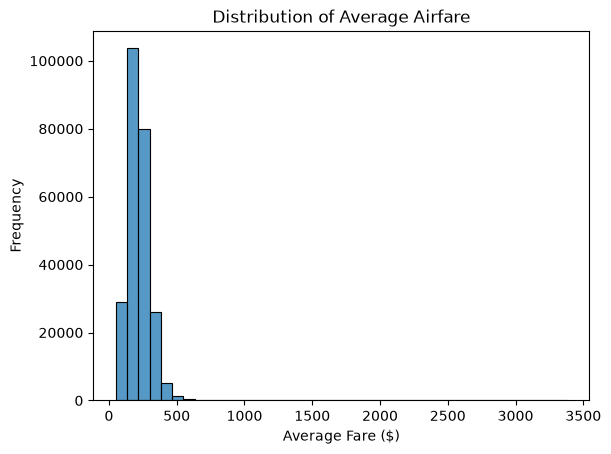

In [42]:
# Plot the distribution of average airfare
sns.histplot(data=df, x="fare", bins=40)

plt.title("Distribution of Average Airfare")
plt.xlabel("Average Fare ($)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Average airfare is strongly right-skewed. Most fares are concentrated in the lower price range, while a relatively small number of observations have very high fares.

## 2. Distribution of Passenger Volume

Examine how passenger volume is distributed across airline markets.

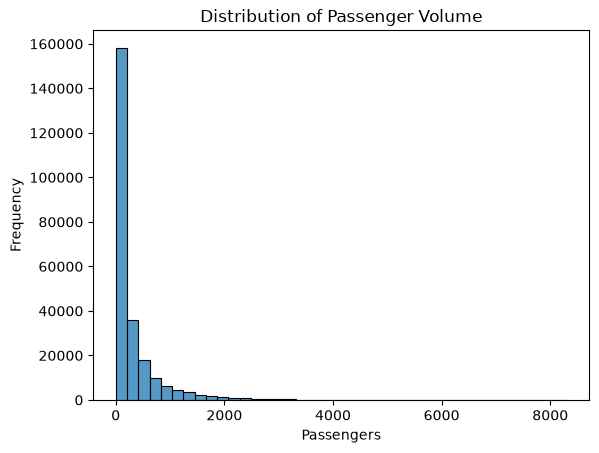

In [43]:
# Plot the distribution of passenger volume
sns.histplot(data=df, x="passengers", bins=40)

plt.title("Distribution of Passenger Volume")
plt.xlabel("Passengers")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Passenger volume is strongly right-skewed. Most market observations have relatively low passenger counts, while a smaller number of high-volume markets create a long right tail.

## 3. Distribution of Route Distance

Examine the distribution of route distances across airline markets.

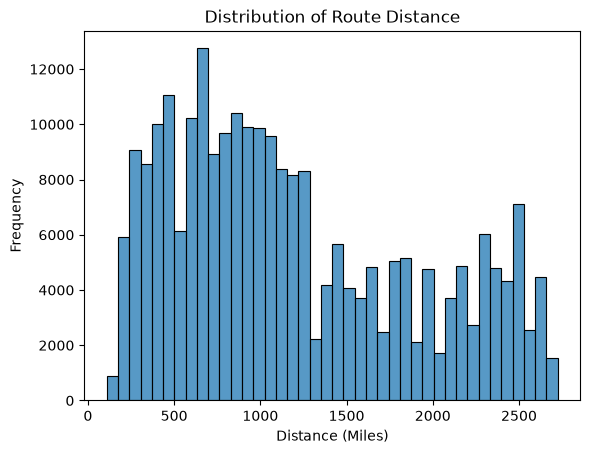

In [44]:
# Plot the distribution of route distance
sns.histplot(data=df, x="nsmiles", bins=40)

plt.title("Distribution of Route Distance")
plt.xlabel("Distance (Miles)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Route distance is broadly distributed across the dataset, with several common distance ranges and no major statistical outliers detected by the IQR method.

## 4. Number of Observations by Year

Examine how the number of airline market observations changes across the years in the dataset.

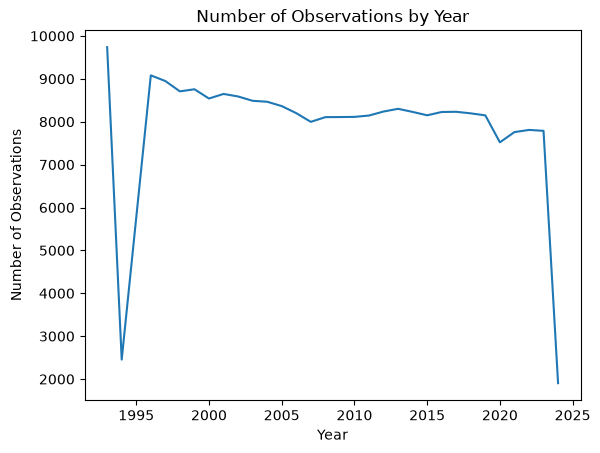

In [45]:
# Count observations for each year
year_counts = df["year"].value_counts().sort_index()

# Plot the number of observations by year
plt.plot(year_counts.index, year_counts.values)

plt.title("Number of Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")

plt.show()

## 5. Most Frequent Largest Carriers

Identify the ten carriers that most frequently appear as the largest carrier in an airline market.

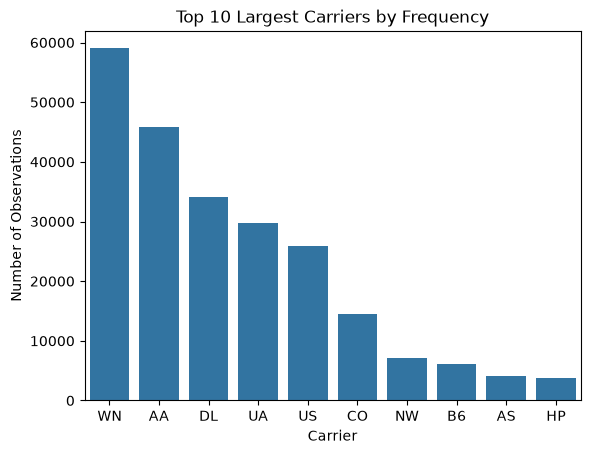

In [46]:
# Identify the top 10 most frequent largest carriers
top_carriers = df["carrier_lg"].value_counts().head(10)

# Plot carrier frequencies
sns.barplot(
    x=top_carriers.index,
    y=top_carriers.values
)

plt.title("Top 10 Largest Carriers by Frequency")
plt.xlabel("Carrier")
plt.ylabel("Number of Observations")

plt.show()

### Interpretation

WN appears most frequently as the largest carrier across the dataset's market observations, followed by AA, DL, and UA.

## 6. Distribution of Largest-Carrier Market Share

Examine the distribution of the market share held by the largest carrier.

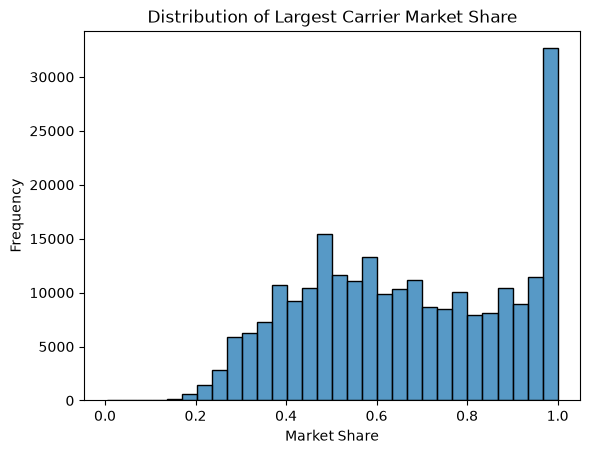

In [47]:
# Plot the distribution of largest-carrier market share
sns.histplot(data=df, x="large_ms", bins=30)

plt.title("Distribution of Largest Carrier Market Share")
plt.xlabel("Market Share")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Largest-carrier market share tends to be relatively high. The median is about 65%, and many observations show the largest carrier holding a very high share, including markets approaching 100%.

## 7. Distribution of Lowest-Fare Carrier Market Share

Examine the distribution of market share held by the lowest-fare carrier.

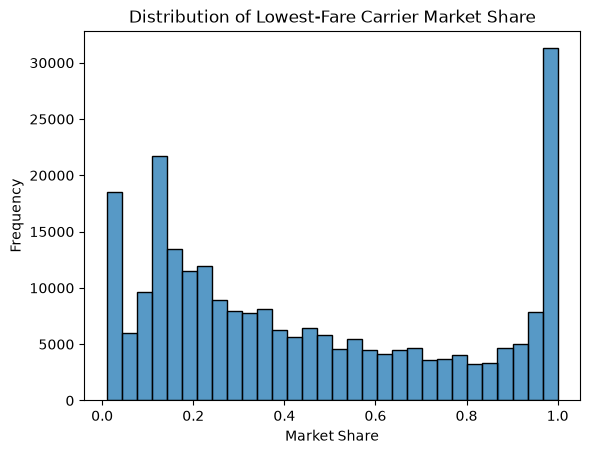

In [48]:
# Plot the distribution of lowest-fare-carrier market share
sns.histplot(data=df, x="lf_ms", bins=30)

plt.title("Distribution of Lowest-Fare Carrier Market Share")
plt.xlabel("Market Share")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The market share of the lowest-fare carrier varies substantially across markets. The median share is about 36%, although a notable number of observations show the lowest-fare carrier holding nearly the entire market.

# Bivariate Analysis

Bivariate analysis examines the relationship between two variables to identify patterns and associations in airline markets.

## 1. Route Distance vs. Average Airfare

Examine whether route distance is related to average airfare.

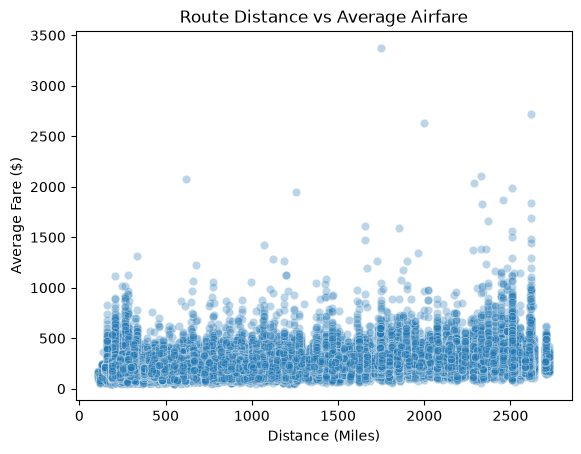

In [49]:
# Plot route distance against average airfare
sns.scatterplot(
    data=df,
    x="nsmiles",
    y="fare",
    alpha=0.3
)

plt.title("Route Distance vs Average Airfare")
plt.xlabel("Distance (Miles)")
plt.ylabel("Average Fare ($)")

plt.show()

### Interpretation

Route distance and average airfare show, at most, a weak positive relationship visually. Fares vary substantially at nearly all route distances, suggesting that distance alone does not strongly determine airfare.

## 2. Passenger Volume vs. Average Airfare

Examine whether passenger volume is related to average airfare.

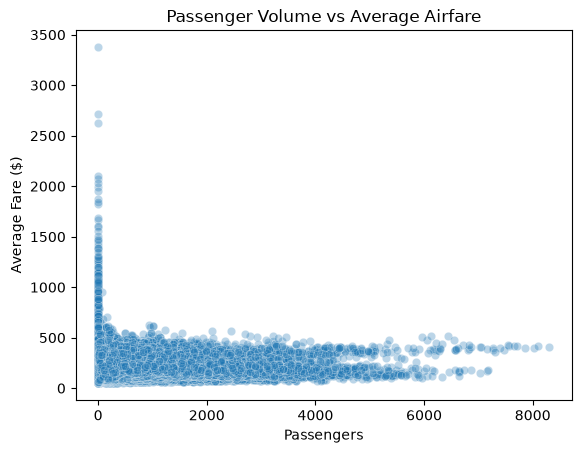

In [50]:
# Plot passenger volume against average airfare
sns.scatterplot(
    data=df,
    x="passengers",
    y="fare",
    alpha=0.3
)

plt.title("Passenger Volume vs Average Airfare")
plt.xlabel("Passengers")
plt.ylabel("Average Fare ($)")

plt.show()

### Interpretation

Higher passenger-volume markets tend to show a narrower and generally lower range of average fares, while low-volume markets exhibit much greater fare variability and include the highest fares.

## 3. Largest-Carrier Market Share vs. Average Airfare

Examine whether the market share of the dominant carrier is related to average airfare.

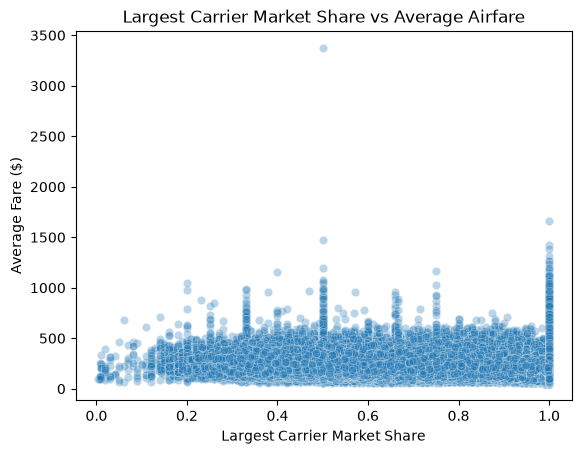

In [51]:
# Plot largest-carrier market share against average airfare
sns.scatterplot(
    data=df,
    x="large_ms",
    y="fare",
    alpha=0.3
)

plt.title("Largest Carrier Market Share vs Average Airfare")
plt.xlabel("Largest Carrier Market Share")
plt.ylabel("Average Fare ($)")

plt.show()

### Interpretation

The scatter plot shows no strong visual relationship between largest-carrier market share and average airfare.

## 4. Lowest-Fare Carrier Fare vs. Largest-Carrier Fare

Compare the fare charged by the lowest-fare carrier with the fare charged by the largest carrier across airline markets.

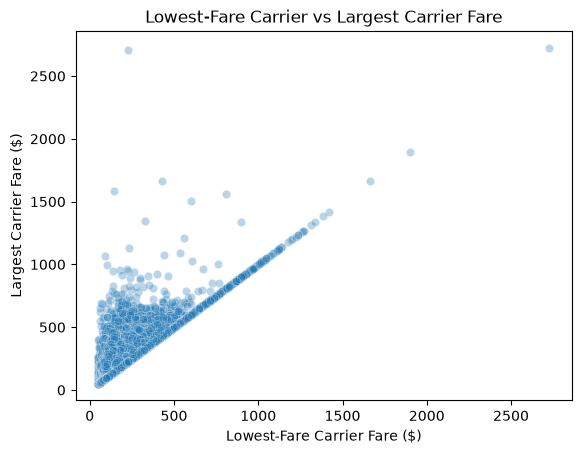

In [52]:
# Compare lowest-fare-carrier fare with largest-carrier fare
sns.scatterplot(
    data=df,
    x="fare_low",
    y="fare_lg",
    alpha=0.3
)

plt.title("Lowest-Fare Carrier vs Largest Carrier Fare")
plt.xlabel("Lowest-Fare Carrier Fare ($)")
plt.ylabel("Largest Carrier Fare ($)")

plt.show()

### Interpretation

Fares of the largest and lowest-fare carriers move closely together across markets, although the largest carrier's fare can be substantially higher in some observations.

## 5. Average Airfare by Largest Carrier

Compare average airfare across the ten carriers that most frequently appear as the largest carrier in a market.

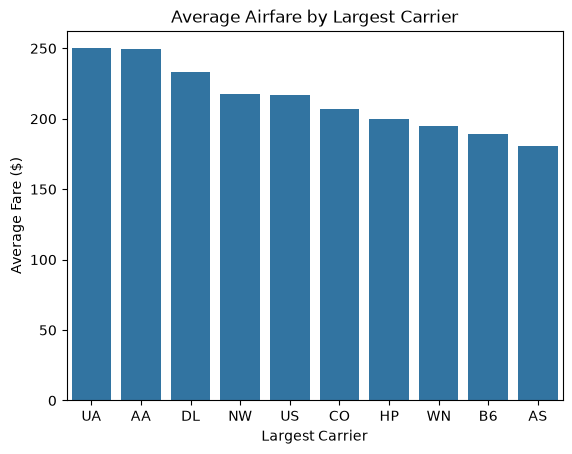

In [53]:
# Identify the 10 most frequently observed largest carriers
top_10 = df["carrier_lg"].value_counts().head(10).index

# Calculate average airfare for markets dominated by each carrier
carrier_fares = (
    df[df["carrier_lg"].isin(top_10)]
    .groupby("carrier_lg")["fare"]
    .mean()
    .sort_values(ascending=False)
)

# Plot average airfare by largest carrier
sns.barplot(
    x=carrier_fares.index,
    y=carrier_fares.values
)

plt.title("Average Airfare by Largest Carrier")
plt.xlabel("Largest Carrier")
plt.ylabel("Average Fare ($)")

plt.show()

### Interpretation

Average airfare varies across markets dominated by different carriers. Among the ten most frequently observed largest carriers, UA and AA are associated with the highest average market fares, while AS, B6, and WN are among the lower-fare groups.

# Multivariate Analysis

Multivariate analysis examines relationships among three or more variables to better understand how airfare, route distance, passenger volume, and market structure interact.

## 1. Route Distance, Airfare, and Passenger Volume

Examine the relationship between route distance and average airfare while using marker size to represent passenger volume.

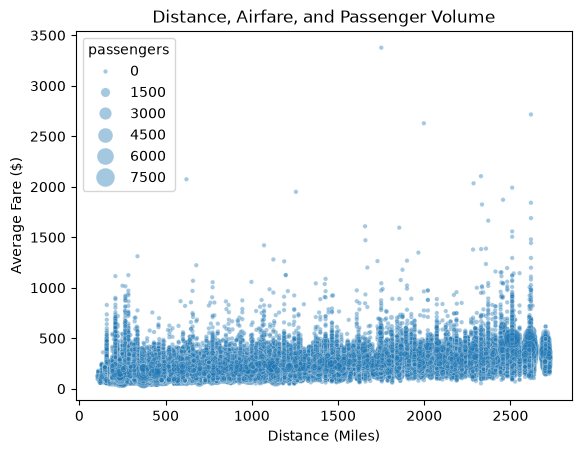

In [54]:
# Examine distance, airfare, and passenger volume together
sns.scatterplot(
    data=df,
    x="nsmiles",
    y="fare",
    size="passengers",
    sizes=(10, 200),
    alpha=0.4
)

plt.title("Distance, Airfare, and Passenger Volume")
plt.xlabel("Distance (Miles)")
plt.ylabel("Average Fare ($)")

plt.show()

### Interpretation

High-passenger markets are generally concentrated within moderate fare levels, while extremely high fares are mostly associated with low-passenger observations across different route distances.

## 2. Passenger-Volume Groups

Divide passenger volume into three groups—Low, Medium, and High—to examine whether the relationship between market share and airfare differs across market sizes.

In [55]:
# Create passenger-volume groups using three quantiles
df["passenger_group"] = pd.qcut(
    df["passengers"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Check the number of observations in each group
print(df["passenger_group"].value_counts())

passenger_group
Medium    82108
Low       82009
High      81838
Name: count, dtype: int64


## 3. Market Share vs. Airfare by Passenger Volume

Examine the relationship between largest-carrier market share and average airfare while distinguishing markets by passenger-volume group.

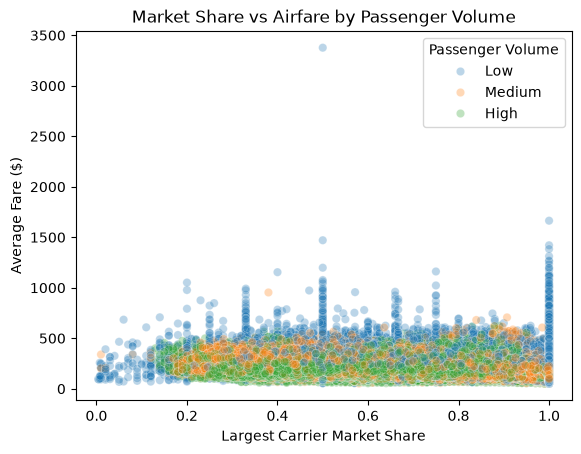

In [56]:
# Plot market share and airfare by passenger-volume group
sns.scatterplot(
    data=df,
    x="large_ms",
    y="fare",
    hue="passenger_group",
    alpha=0.3
)

plt.title("Market Share vs Airfare by Passenger Volume")
plt.xlabel("Largest Carrier Market Share")
plt.ylabel("Average Fare ($)")
plt.legend(title="Passenger Volume")

plt.show()

# Multiple Linear Regression

Use multiple linear regression to examine how route distance, passenger volume, largest-carrier market share, lowest-fare-carrier market share, and year are jointly associated with average airfare.

In [57]:
# Select variables for multiple linear regression
# Remove observations with missing values in the selected variables
reg_data = df[
    [
        "fare",
        "nsmiles",
        "passengers",
        "large_ms",
        "lf_ms",
        "year"
    ]
].dropna()

# Preview the regression dataset
print(reg_data.head())

# Display the number of observations used
print("\nRows used:", len(reg_data))

     fare  nsmiles  passengers  large_ms   lf_ms  year
0   81.43      970         180    1.0000  1.0000  2021
1  208.93      970          19    0.4659  0.1193  2021
2  184.56      580         204    0.9968  0.9968  2021
3  182.64      580         264    0.9774  0.9774  2021
4  177.11      328         398    0.6061  0.3939  2021

Rows used: 244343


In [58]:
# Define predictor variables
X = reg_data[
    ["nsmiles", "passengers", "large_ms", "lf_ms", "year"]
]

# Define the target variable
y = reg_data["fare"]

# Add an intercept to the regression model
X = sm.add_constant(X)

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                 2.302e+04
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:09:03   Log-Likelihood:            -1.3688e+06
No. Observations:              244343   AIC:                         2.738e+06
Df Residuals:                  244337   BIC:                         2.738e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3075.3147     31.064    -98.998      0.0

# Correlation Analysis

Calculate correlations among key numerical airline market variables to measure the direction and strength of their linear relationships.

In [59]:
# Select numerical variables for correlation analysis
corr_vars = [
    "nsmiles",
    "passengers",
    "fare",
    "large_ms",
    "fare_lg",
    "lf_ms",
    "fare_low"
]

# Calculate the correlation matrix
corr_matrix = df[corr_vars].corr()

# Display correlations rounded to two decimal places
print(corr_matrix.round(2))

            nsmiles  passengers  fare  large_ms  fare_lg  lf_ms  fare_low
nsmiles        1.00       -0.08  0.50     -0.40     0.48  -0.25      0.42
passengers    -0.08        1.00 -0.17     -0.08    -0.13  -0.12     -0.21
fare           0.50       -0.17  1.00     -0.18     0.96  -0.19      0.87
large_ms      -0.40       -0.08 -0.18      1.00    -0.18   0.53     -0.08
fare_lg        0.48       -0.13  0.96     -0.18     1.00  -0.24      0.83
lf_ms         -0.25       -0.12 -0.19      0.53    -0.24   1.00      0.06
fare_low       0.42       -0.21  0.87     -0.08     0.83   0.06      1.00


## Correlation Heatmap

Visualize the correlation matrix to make relationships among the selected numerical variables easier to compare.

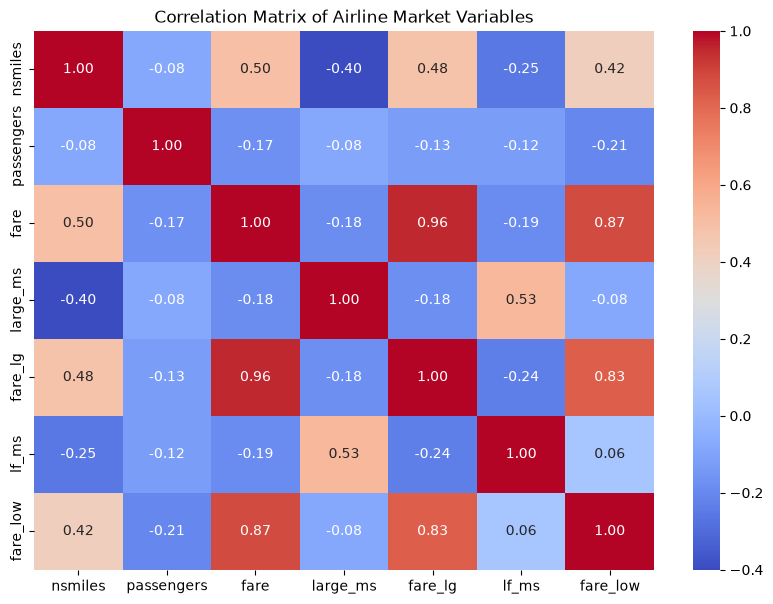

In [60]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Airline Market Variables")

plt.show()

# Airfare Trend Over Time

Examine how average airfare changed from 1993 to 2024 by calculating the mean airfare for each year.

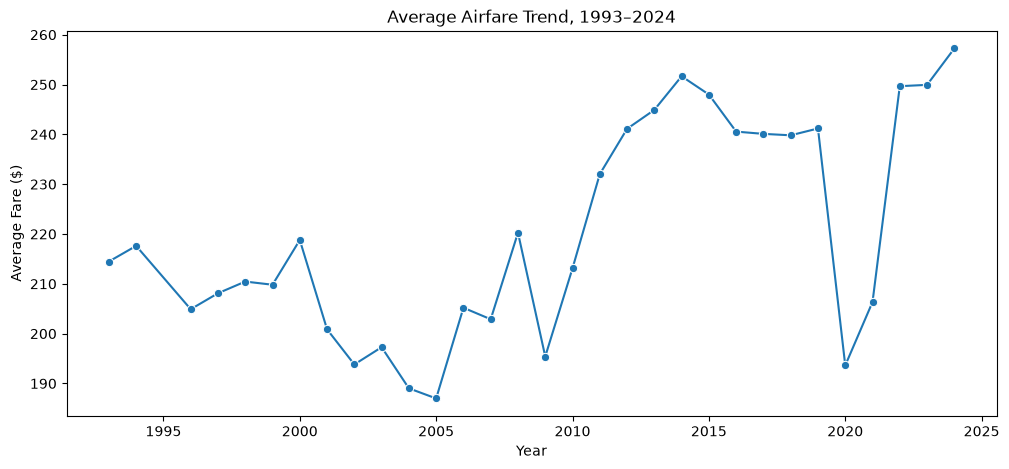

In [61]:
# Calculate average airfare for each year
yearly_fare = df.groupby("year")["fare"].mean()

# Create the yearly airfare trend
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=yearly_fare.index,
    y=yearly_fare.values,
    marker="o"
)

plt.title("Average Airfare Trend, 1993–2024")
plt.xlabel("Year")
plt.ylabel("Average Fare ($)")

plt.show()

# Feature Exploration

Feature exploration identified the variables most associated with airfare. `fare_lg` (0.96) and `fare_low` (0.87) showed the strongest positive correlations with average fare, while route distance (`nsmiles`) showed a moderate correlation (0.50).

The regression model explained 32% of airfare variation (R² = 0.320). Overall, the results indicate that airfare is associated with route distance, passenger volume, carrier market share, and time, highlighting the combined influence of route and market characteristics.

# Key Insights and Conclusion

The EDA identified several important patterns in U.S. airline fares:

- Airfare and passenger volume are right-skewed, showing substantial variation across markets.
- Route distance has a moderate positive relationship with airfare (r = 0.50).
- Passenger volume shows a weak negative relationship with airfare (r = -0.17).
- Carrier fares are strongly related to overall market airfare, particularly `fare_lg` (r = 0.96) and `fare_low` (r = 0.87).
- The regression model explains 32% of airfare variation, indicating that airfare is influenced by multiple route, market, and time-related factors.

Overall, the analysis shows that airfare varies with route characteristics, passenger demand, carrier pricing, market structure, and time.